# Session 3 — Solutions

Worked solutions for signal region, cutflow, yields, and control regions (Z CR, Top CR). Uses one file per dataset from `config/datasets_2017_short.yaml`; SR plots are MC-only; data can be plotted in CRs.

## Setup and cutflow (Ex 3.1, 3.3)


In [1]:
# Ensure project root is on sys.path (for SWAN / any kernel)
import sys, os
sys.path.append("..")


import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
import pandas as pd

from config.datasets_2017 import get_short_datasets_meta
from processor.bbdm_processor import get_nanoevents, select_good_jets, count_bjets, n_tight_leptons, MET_SR_MIN

# Normalization
LUMI_PB = 41.5 * 1000

# Load one file per dataset from config/datasets_2017_short.yaml (limit to 10k events per file)
MAX_EVENTS = 10_000
datasets = get_short_datasets_meta()

events_by_dataset = {}
labels = {}
xsecs = {}
is_data = {}
norm_factors = {}

for name, meta in datasets.items():
    labels[name] = meta.get("label", name)
    xsecs[name] = meta.get("xsec")
    is_data[name] = bool(meta.get("isData", False))
    path_list = meta.get("files", [])
    if path_list:
        ev = get_nanoevents(path_list[0])[:MAX_EVENTS]
        events_by_dataset[name] = ev
        if not is_data[name]:
            xsec = xsecs.get(name)
            if xsec is None:
                norm_factors[name] = None
            else:
                norm_factors[name] = (float(xsec) * LUMI_PB) / float(len(ev))

# MC-only for SR: background names (exclude data and signal)
bkg_names = [k for k in events_by_dataset if (not is_data.get(k, False)) and ("bbDM" not in k)]

# Matplotlib legend labels (LaTeX)
latex_labels = {
    "DYJets": r"$Z(\ell\ell)+$jets",
    "ZJets": r"$Z(\nu\bar{\nu})+$jets",
    "WJets": r"$W(\ell\nu)+$jets",
    "DIBOSON": r"WW",
    "STop": r"Single $t$",
    "Top": r"$t\bar{t}$",
    "QCD": r"QCD",
    "SMH": r"SMH",
    "bbDM_2HDMa_LO_5f": r"bbDM (2HDM+a)",
    "MET_Run2017B": r"Data",
}

# Sanity printout: xsec, N, normalization factor
for name in bkg_names:
    print(name, "xsec=", xsecs.get(name), "N=", len(events_by_dataset[name]), "norm=", norm_factors.get(name))

# Cutflow per dataset (Ex 3.1)
def run_cutflow(events):
    good_jets = select_good_jets(events)
    njets = ak.num(good_jets)
    nlep = n_tight_leptons(events)
    met = events.MET.pt
    met_phi = events.MET.phi
    dphi = np.abs(good_jets.phi - met_phi)
    dphi = ak.where(dphi > np.pi, 2 * np.pi - dphi, dphi)
    min_dphi = ak.min(dphi, axis=1)
    dphi_cut = min_dphi > 0.5

    jets2 = ak.pad_none(good_jets, 2)
    lead2_b = ak.fill_none(jets2[:, 0].btagDeepFlavB > 0.2783, False) & ak.fill_none(jets2[:, 1].btagDeepFlavB > 0.2783, False)
    jets_2to3 = (njets >= 2) & (njets <= 3)
    sr_jets = jets_2to3 & lead2_b

    n1 = ak.sum(sr_jets)
    n2 = ak.sum(sr_jets & (nlep == 0))
    n3 = ak.sum(sr_jets & (nlep == 0) & dphi_cut)
    n4 = ak.sum(sr_jets & (nlep == 0) & dphi_cut & (met > MET_SR_MIN))
    return {"presel": int(n1), "0lep": int(n2), "Δφ>0.5": int(n3), "MET>200": int(n4)}

cutflow_by_dataset = {name: run_cutflow(ev) for name, ev in events_by_dataset.items()}
for name in cutflow_by_dataset:
    print(labels.get(name, name), cutflow_by_dataset[name])

# Yield table (Ex 3.3): one row per cut, one column per process
cuts = ["2≤Njets≤3, leading 2 b-tag", "0 leptons", "Δφ>0.5", "MET>200 GeV"]
keys = ["presel", "0lep", "Δφ>0.5", "MET>200"]
data = {"Cut": cuts}
for name in list(events_by_dataset.keys())[:6]:
    data[labels.get(name, name)] = [cutflow_by_dataset[name][k] for k in keys]
df = pd.DataFrame(data)
print(df)

DYJets xsec= 6.982 N= 10000 norm= 28.9753
ZJets xsec= 13.11 N= 10000 norm= 54.4065
WJets xsec= 57.91 N= 1590 norm= 1511.4874213836479
DIBOSON xsec= 77.9187 N= 10000 norm= 323.36260500000003
STop xsec= 136.02 N= 10000 norm= 564.483
Top xsec= 365.2482 N= 10000 norm= 1515.7800300000001
QCD xsec= 1094 N= 10000 norm= 4540.1
SMH xsec= None N= 10000 norm= None
Data MET 2017 {'presel': 32, '0lep': 29, 'Δφ>0.5': 6, 'MET>200': 0}
Z(ll)+jets  {'presel': 15, '0lep': 6, 'Δφ>0.5': 3, 'MET>200': 0}
Z(#nu#nu)+jets  {'presel': 62, '0lep': 62, 'Δφ>0.5': 44, 'MET>200': 18}
W(l#nu)+jets  {'presel': 2, '0lep': 2, 'Δφ>0.5': 1, 'MET>200': 0}
WW  {'presel': 5, '0lep': 3, 'Δφ>0.5': 3, 'MET>200': 0}
Single t  {'presel': 312, '0lep': 255, 'Δφ>0.5': 165, 'MET>200': 2}
t#bar{t}  {'presel': 345, '0lep': 222, 'Δφ>0.5': 163, 'MET>200': 2}
QCD  {'presel': 28, '0lep': 28, 'Δφ>0.5': 16, 'MET>200': 0}
SMH  {'presel': 145, '0lep': 99, 'Δφ>0.5': 67, 'MET>200': 1}
bbDM (2HDM+a) {'presel': 1991, '0lep': 1948, 'Δφ>0.5': 1725,

## MET in signal region — MC only (Ex 3.2)


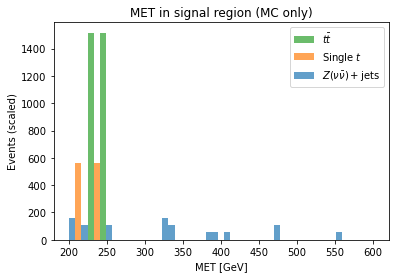

In [2]:
# MET in SR: MC-only stacked (no data in signal region), scaled to 41.5/fb
bins_met = np.linspace(200, 600, 50)
met_arrays, w_arrays, leg_labels = [], [], []

for name in bkg_names:
    if name not in events_by_dataset:
        continue
    norm = norm_factors.get(name)
    if norm is None:
        continue

    ev = events_by_dataset[name]
    good_jets = select_good_jets(ev)
    njets = ak.num(good_jets)
    nlep = n_tight_leptons(ev)
    met = ev.MET.pt

    met_phi = ev.MET.phi
    dphi = np.abs(good_jets.phi - met_phi)
    dphi = ak.where(dphi > np.pi, 2 * np.pi - dphi, dphi)
    min_dphi = ak.min(dphi, axis=1)
    dphi_cut = min_dphi > 0.5

    jets2 = ak.pad_none(good_jets, 2)
    lead2_b = ak.fill_none(jets2[:, 0].btagDeepFlavB > 0.2783, False) & ak.fill_none(jets2[:, 1].btagDeepFlavB > 0.2783, False)

    sr_mask = (njets >= 2) & (njets <= 3) & lead2_b & (nlep == 0) & (met > MET_SR_MIN) & dphi_cut
    met_sr = met[sr_mask]
    flat = ak.to_numpy(ak.ravel(met_sr))
    if len(flat) == 0:
        continue

    met_arrays.append(flat)
    w_arrays.append(np.full_like(flat, norm, dtype=float))
    leg_labels.append(latex_labels.get(name, labels.get(name, name)))

if met_arrays:
    plt.hist(met_arrays, bins=bins_met, weights=w_arrays, label=leg_labels, stacked=True, histtype="stepfilled", alpha=0.7)
plt.xlabel("MET [GeV]")
plt.ylabel("Events (scaled)")
plt.title("MET in signal region (MC only)")
plt.legend()
plt.show()

## Z control region (dilepton) — data and MC

Preselection **recoil** > 250 GeV (U = −(pTmiss + Σ pT^lep)), ≥1 jet, leading jet pT > 100 GeV; then exactly 2 OSSF leptons (ee or μμ), leading lepton pT > 30 GeV, 70 < m_ℓℓ < 110 GeV.


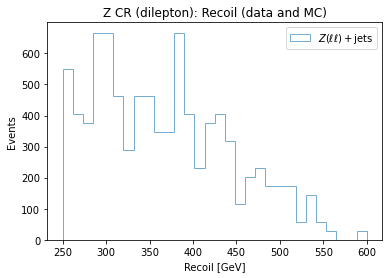

In [3]:
from processor.bbdm_processor import select_tight_electrons, select_tight_muons, recoil_pt

PRESEL_RECOIL_MIN = 250.0
LEAD_JET_PT_MIN = 100.0
Z_CR_MLL_LO, Z_CR_MLL_HI = 70.0, 110.0
LEAD_LEP_PT_CR = 30.0

def z_cr_mask(events):
    good_jets = select_good_jets(events)
    njets = ak.num(good_jets)
    lead_jet_pt = ak.fill_none(ak.firsts(good_jets.pt), 0.0)
    met_pt, met_phi = events.MET.pt, events.MET.phi
    tight_ele = select_tight_electrons(events)
    tight_mu = select_tight_muons(events)
    nele, nmu = ak.count(tight_ele.pt, axis=1), ak.count(tight_mu.pt, axis=1)
    two_ee = (nele == 2) & (nmu == 0) & (ak.sum(tight_ele.charge, axis=1) == 0)
    two_mumu = (nele == 0) & (nmu == 2) & (ak.sum(tight_mu.charge, axis=1) == 0)
    tight_ele_pad = ak.pad_none(tight_ele, 2)
    tight_mu_pad = ak.pad_none(tight_mu, 2)
    pair_ee = tight_ele_pad[:, 0] + tight_ele_pad[:, 1]
    pair_mumu = tight_mu_pad[:, 0] + tight_mu_pad[:, 1]
    sum_lep_px = ak.where(two_ee, ak.fill_none(pair_ee.pt, 0.0) * np.cos(ak.fill_none(pair_ee.phi, 0.0)), ak.where(two_mumu, ak.fill_none(pair_mumu.pt, 0.0) * np.cos(ak.fill_none(pair_mumu.phi, 0.0)), ak.full_like(met_pt, 0.0)))
    sum_lep_py = ak.where(two_ee, ak.fill_none(pair_ee.pt, 0.0) * np.sin(ak.fill_none(pair_ee.phi, 0.0)), ak.where(two_mumu, ak.fill_none(pair_mumu.pt, 0.0) * np.sin(ak.fill_none(pair_mumu.phi, 0.0)), ak.full_like(met_pt, 0.0)))
    recoil = recoil_pt(met_pt, met_phi, sum_lep_px, sum_lep_py)
    dphi_j = np.abs(good_jets.phi - met_phi)
    dphi_j = ak.where(dphi_j > np.pi, 2 * np.pi - dphi_j, dphi_j)
    min_dphi = ak.min(dphi_j, axis=1)
    dphi_cut = min_dphi > 0.5
    presel = (recoil > PRESEL_RECOIL_MIN) & (njets >= 1) & (lead_jet_pt > LEAD_JET_PT_MIN) & dphi_cut
    mll_ee = ak.where(two_ee, ak.fill_none(pair_ee.mass, -1.0), ak.full_like(met_pt, -1.0))
    mll_mumu = ak.where(two_mumu, ak.fill_none(pair_mumu.mass, -1.0), ak.full_like(met_pt, -1.0))
    mll = ak.where(two_ee, mll_ee, ak.where(two_mumu, mll_mumu, ak.full_like(met_pt, -1.0)))
    lead_lep_pt = ak.where(two_ee, ak.max(tight_ele.pt, axis=1), ak.where(two_mumu, ak.max(tight_mu.pt, axis=1), ak.full_like(met_pt, 0.0)))
    return presel & (two_ee | two_mumu) & (lead_lep_pt > LEAD_LEP_PT_CR) & (mll > Z_CR_MLL_LO) & (mll < Z_CR_MLL_HI)

def z_cr_recoil(events):
    met_pt, met_phi = events.MET.pt, events.MET.phi
    tight_ele, tight_mu = select_tight_electrons(events), select_tight_muons(events)
    nele, nmu = ak.count(tight_ele.pt, axis=1), ak.count(tight_mu.pt, axis=1)
    two_ee = (nele == 2) & (nmu == 0) & (ak.sum(tight_ele.charge, axis=1) == 0)
    two_mumu = (nele == 0) & (nmu == 2) & (ak.sum(tight_mu.charge, axis=1) == 0)
    tight_ele_pad = ak.pad_none(tight_ele, 2)
    tight_mu_pad = ak.pad_none(tight_mu, 2)
    pair_ee = tight_ele_pad[:, 0] + tight_ele_pad[:, 1]
    pair_mumu = tight_mu_pad[:, 0] + tight_mu_pad[:, 1]
    sum_lep_px = ak.where(two_ee, ak.fill_none(pair_ee.pt, 0.0) * np.cos(ak.fill_none(pair_ee.phi, 0.0)), ak.where(two_mumu, ak.fill_none(pair_mumu.pt, 0.0) * np.cos(ak.fill_none(pair_mumu.phi, 0.0)), ak.full_like(met_pt, 0.0)))
    sum_lep_py = ak.where(two_ee, ak.fill_none(pair_ee.pt, 0.0) * np.sin(ak.fill_none(pair_ee.phi, 0.0)), ak.where(two_mumu, ak.fill_none(pair_mumu.pt, 0.0) * np.sin(ak.fill_none(pair_mumu.phi, 0.0)), ak.full_like(met_pt, 0.0)))
    return recoil_pt(met_pt, met_phi, sum_lep_px, sum_lep_py)

fig, ax = plt.subplots()
for name in list(events_by_dataset.keys())[:5]:
    ev = events_by_dataset[name]
    mask = z_cr_mask(ev)
    recoil = z_cr_recoil(ev)[mask]
    if len(ak.ravel(recoil)) == 0:
        continue
    if is_data.get(name, False):
        w = None
    else:
        norm = norm_factors.get(name)
        if norm is None:
            continue
        w = np.full_like(ak.to_numpy(ak.ravel(recoil)), norm, dtype=float)
    ax.hist(ak.to_numpy(ak.ravel(recoil)), bins=30, range=(250, 600), weights=w, label=latex_labels.get(name, labels.get(name, name)), alpha=0.6, histtype="step")
ax.set_xlabel("Recoil [GeV]")
ax.set_ylabel("Events")
ax.set_title("Z CR (dilepton): Recoil (data and MC)")
ax.legend()
plt.show()

## Top control region (single-lepton) — data and MC

Exactly one lepton pT > 30 GeV; m_T < 160 GeV; ≥2 b-jets; ≥2 non-b jets.

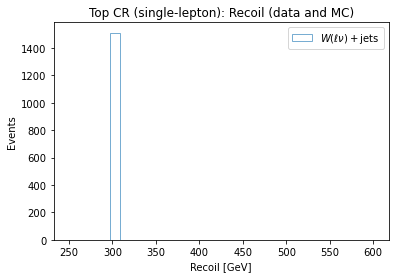

In [4]:
TOP_CR_MT_MAX = 160.0

def top_cr_mask(events):
    good_jets = select_good_jets(events)
    njets = ak.num(good_jets)
    nbjets = count_bjets(good_jets)
    lead_jet_pt = ak.fill_none(ak.firsts(good_jets.pt), 0.0)
    met_pt, met_phi = events.MET.pt, events.MET.phi
    tight_ele = select_tight_electrons(events)
    tight_mu = select_tight_muons(events)
    one_ele = (ak.count(tight_ele.pt, axis=1) == 1) & (ak.count(tight_mu.pt, axis=1) == 0)
    one_mu = (ak.count(tight_ele.pt, axis=1) == 0) & (ak.count(tight_mu.pt, axis=1) == 1)
    lep_pt = ak.fill_none(ak.where(one_ele, ak.firsts(tight_ele.pt), ak.where(one_mu, ak.firsts(tight_mu.pt), ak.full_like(met_pt, 0.0))), 0.0)
    lep_phi = ak.fill_none(ak.where(one_ele, ak.firsts(tight_ele.phi), ak.where(one_mu, ak.firsts(tight_mu.phi), ak.full_like(met_pt, 0.0))), 0.0)
    sum_lep_px = lep_pt * np.cos(lep_phi)
    sum_lep_py = lep_pt * np.sin(lep_phi)
    recoil = recoil_pt(met_pt, met_phi, sum_lep_px, sum_lep_py)
    dphi_j = np.abs(good_jets.phi - met_phi)
    dphi_j = ak.where(dphi_j > np.pi, 2 * np.pi - dphi_j, dphi_j)
    min_dphi = ak.min(dphi_j, axis=1)
    dphi_cut = min_dphi > 0.5
    presel = (recoil > PRESEL_RECOIL_MIN) & (njets >= 1) & (lead_jet_pt > LEAD_JET_PT_MIN) & dphi_cut
    dphi = np.abs(ak.to_numpy(met_phi) - ak.to_numpy(lep_phi))
    dphi = np.where(dphi > np.pi, 2 * np.pi - dphi, dphi)
    mt = np.sqrt(2.0 * ak.to_numpy(met_pt) * ak.to_numpy(lep_pt) * (1.0 - np.cos(dphi)))
    mt = ak.Array(mt)
    n_non_b = njets - nbjets
    return presel & (n_tight_leptons(events) == 1) & (lep_pt > LEAD_LEP_PT_CR) & (mt < TOP_CR_MT_MAX) & (nbjets >= 2) & (n_non_b >= 2)

def top_cr_recoil(events):
    met_pt, met_phi = events.MET.pt, events.MET.phi
    tight_ele, tight_mu = select_tight_electrons(events), select_tight_muons(events)
    one_ele = (ak.count(tight_ele.pt, axis=1) == 1) & (ak.count(tight_mu.pt, axis=1) == 0)
    one_mu = (ak.count(tight_ele.pt, axis=1) == 0) & (ak.count(tight_mu.pt, axis=1) == 1)
    lep_pt = ak.fill_none(ak.where(one_ele, ak.firsts(tight_ele.pt), ak.where(one_mu, ak.firsts(tight_mu.pt), ak.full_like(met_pt, 0.0))), 0.0)
    lep_phi = ak.fill_none(ak.where(one_ele, ak.firsts(tight_ele.phi), ak.where(one_mu, ak.firsts(tight_mu.phi), ak.full_like(met_pt, 0.0))), 0.0)
    return recoil_pt(met_pt, met_phi, lep_pt * np.cos(lep_phi), lep_pt * np.sin(lep_phi))

fig, ax = plt.subplots()
for name in list(events_by_dataset.keys())[:5]:
    ev = events_by_dataset[name]
    mask = top_cr_mask(ev)
    recoil = top_cr_recoil(ev)[mask]
    if len(ak.ravel(recoil)) == 0:
        continue
    if is_data.get(name, False):
        w = None
    else:
        norm = norm_factors.get(name)
        if norm is None:
            continue
        w = np.full_like(ak.to_numpy(ak.ravel(recoil)), norm, dtype=float)
    ax.hist(ak.to_numpy(ak.ravel(recoil)), bins=30, range=(250, 600), weights=w, label=latex_labels.get(name, labels.get(name, name)), alpha=0.6, histtype="step")
ax.set_xlabel("Recoil [GeV]")
ax.set_ylabel("Events")
ax.set_title("Top CR (single-lepton): Recoil (data and MC)")
ax.legend()
plt.show()

## Comparison: MET presel vs SR (Ex 3.4)

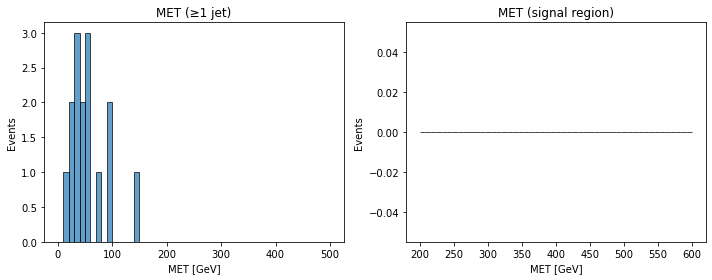

In [5]:
# Use first MC background for comparison plot
name = bkg_names[0] if bkg_names else list(events_by_dataset.keys())[0]
ev = events_by_dataset[name]
good_jets = select_good_jets(ev)
njets = ak.num(good_jets)
nlep = n_tight_leptons(ev)
met = ev.MET.pt

jets2 = ak.pad_none(good_jets, 2)
lead2_b = ak.fill_none(jets2[:, 0].btagDeepFlavB > 0.2783, False) & ak.fill_none(jets2[:, 1].btagDeepFlavB > 0.2783, False)

sr_mask = (njets >= 2) & (njets <= 3) & lead2_b & (nlep == 0) & (met > MET_SR_MIN)
met_presel = met[(njets >= 2) & (njets <= 3) & lead2_b]
met_sr = met[sr_mask]

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(ak.to_numpy(ak.ravel(met_presel)), bins=50, range=(0, 500), edgecolor="black", alpha=0.7, label="Presel")
ax[0].set_xlabel("MET [GeV]")
ax[0].set_ylabel("Events")
ax[0].set_title("MET (≥1 jet)")
ax[1].hist(ak.to_numpy(ak.ravel(met_sr)), bins=50, range=(200, 600), edgecolor="black", alpha=0.7, label="SR")
ax[1].set_xlabel("MET [GeV]")
ax[1].set_ylabel("Events")
ax[1].set_title("MET (signal region)")
plt.tight_layout()
plt.show()